## **Alexa Dandridge** 

#### **Take-Home Final Exam - Due Sunday, May 10th, 2026**

# 1. Exploratory Data Analysis:

Include a small number of relevant summaries or plots and focus on insights that influenced your modeling.

In [22]:
# importing necessary packages
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
import optuna
import category_encoders as ce
import matplotlib.pyplot as plt
from feature_engine.encoding import RareLabelEncoder, CountFrequencyEncoder
from feature_engine.discretisation import EqualFrequencyDiscretiser
from feature_engine.selection import DropConstantFeatures
from sklearn.preprocessing import PolynomialFeatures
from sklearn.inspection import permutation_importance
from sklearn.naive_bayes import GaussianNB 

In [23]:
# loading in the data
df = pd.read_csv("midterm_train.csv")
df.head()

,id,customer_age,occupation_type,relationship_status,education_background,has_credit_issue,mortgage_status,personal_loan_status,last_contact_month,day_of_week,contact_time_minutes,contact_attempt_count,days_since_prior_contact,prior_contact_count,prior_outcome_status,economic_activity_change,consumer_price_index,consumer_confidence_index,reference_interest_rate,employment_level_index,accepted_offer,is_repeat_customer,recent_contact_flag
0,12556,28,services,married,high.school,no,yes,no,jul,tue,286,1,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,0,0,0
1,35451,27,admin.,married,university.degree,no,yes,yes,jul,fri,178,2,999,0,nonexistent,1.4,93.918,-42.7,4.959,5228.1,0,0,0
2,30592,43,self-employed,married,high.school,unknown,yes,no,apr,wed,345,1,999,0,nonexistent,-1.8,93.075,-47.1,1.498,5099.1,0,0,0
3,17914,43,admin.,single,university.degree,no,yes,no,aug,fri,213,2,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,0,0,0
4,3315,41,admin.,married,unknown,no,no,no,sep,wed,845,1,7,3,success,-1.1,94.199,-37.5,0.886,4963.6,1,1,1


In [24]:
# making a sweetviz report to understand the data better
import sweetviz as sv
report = sv.analyze(df)
report.show_html("sweetviz_report.html")

                                             |          | [  0%]   00:00 -> (? left)

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


Based on the SweetViz Report, some things that I took note of are:

There are no missing values. The target variable (accepted_offer) is heavily imbalanced. The majority are not accepting (0) at 86%, and only 14% accepting the offer (1). This makes me think that I should use more metrics to understand whether my models are good at predicting. The variable, days_since_prior_contact, has so many values at 999, which may just be the longest time possible. This may have to have some adjustment made to it (feature engineering) to make this more meaningful. Some of the other variables, like contact_time_minutes and contact_attempt_count, are pretty skewed. 

In [25]:
# performing some basic EDA
print(df.info())
print(df.describe())
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32950 entries, 0 to 32949
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         32950 non-null  int64  
 1   customer_age               32950 non-null  int64  
 2   occupation_type            32950 non-null  object 
 3   relationship_status        32950 non-null  object 
 4   education_background       32950 non-null  object 
 5   has_credit_issue           32950 non-null  object 
 6   mortgage_status            32950 non-null  object 
 7   personal_loan_status       32950 non-null  object 
 8   last_contact_month         32950 non-null  object 
 9   day_of_week                32950 non-null  object 
 10  contact_time_minutes       32950 non-null  int64  
 11  contact_attempt_count      32950 non-null  int64  
 12  days_since_prior_contact   32950 non-null  int64  
 13  prior_contact_count        32950 non-null  int

This confirmed that there are no missing values. There are also a mix of feature types (float64, int64, and objects). I am also noting that I will have to drop the ID column in preprocessing because that should not be used in modeling, it is just an identifier. 

In [26]:
df["accepted_offer"].value_counts(normalize=True)

accepted_offer
0    0.887253
1    0.112747
Name: proportion, dtype: float64

This cell shows the imbalance in the target class.

Now that I have done some basics, I am going to make some graphs. 

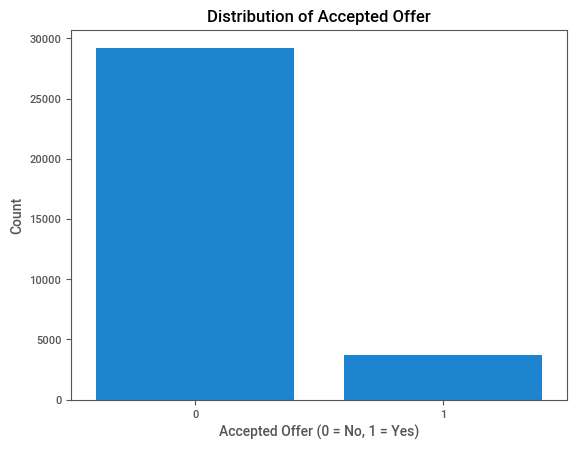

In [27]:
# Making a graph to show the distribution of the target variable
import seaborn as sns
sns.countplot(x="accepted_offer", data=df)
plt.title("Distribution of Accepted Offer")
plt.xlabel("Accepted Offer (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

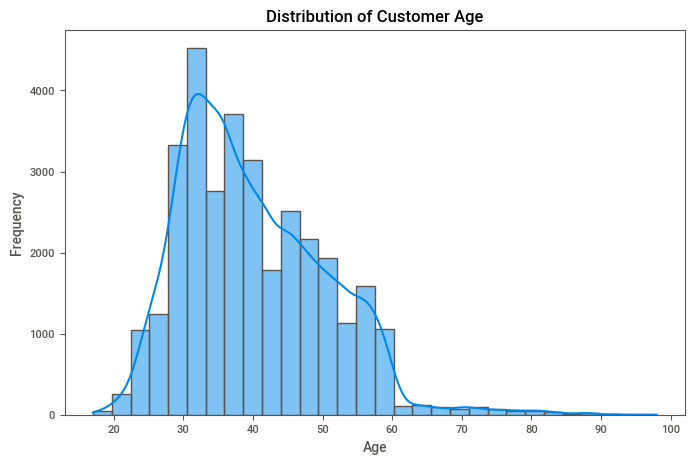

In [28]:
# showing the distrobution of ages
plt.figure(figsize=(8,5))
sns.histplot(df["customer_age"], bins=30, kde=True)
plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

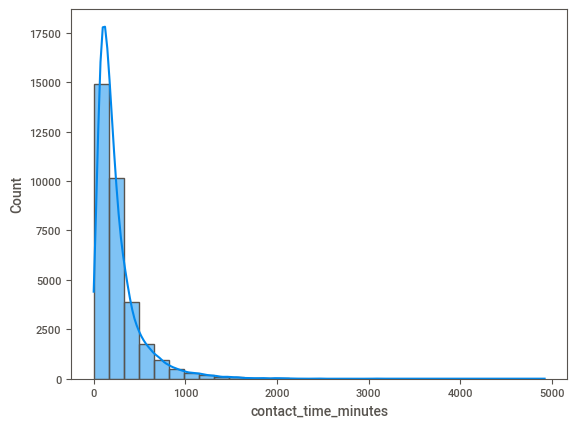

In [29]:
sns.histplot(df["contact_time_minutes"], bins=30, kde=True)
plt.show()

After EDA, I learned that the dataset has 32,950 observations and 23 columns, with both categorical and numerical variables. The target class is binary and very imbalanced, which suggests that I need to use mutliple metrics when evaluating and use classification models. Some of the varaibles are skewed, so I will also explore some feature transformations when modeling. 

# 2. Data Preparation:

Show the preprocessing steps used for modeling.

In [30]:
# separating the features and target 
X = df.drop("accepted_offer", axis=1)
y = df["accepted_offer"]

In [31]:
# dropping id column because it is only an identifier
X = X.drop("id", axis=1)

#printing the shape of the data
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (32950, 21)
Shape of y: (32950,)


In [32]:
# doing the train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# checking the shapes of the splits
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (26360, 21)
Shape of X_test: (6590, 21)
Shape of y_train: (26360,)
Shape of y_test: (6590,)


In preprocessing, I split the data into training and validation sets using an 80/20 split. Stratification (straify = y) was included due to the class imbalance.

In [33]:
# identifyingthe categorical and numerical columns
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
# checking the categorical and numerical columns
print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['occupation_type', 'relationship_status', 'education_background', 'has_credit_issue', 'mortgage_status', 'personal_loan_status', 'last_contact_month', 'day_of_week', 'prior_outcome_status']
Numerical columns: ['customer_age', 'contact_time_minutes', 'contact_attempt_count', 'days_since_prior_contact', 'prior_contact_count', 'economic_activity_change', 'consumer_price_index', 'consumer_confidence_index', 'reference_interest_rate', 'employment_level_index', 'is_repeat_customer', 'recent_contact_flag']


I separated features by data type so categorical variables can be one-hot encoded and numerical variables can be scaled. I will do these two preprocessing steps after I do feature engineering. 

# 3. Feature Engineering or Feature Selection:

Evaluate whether feature engineering or
feature selection improved or simplified your model.

In [34]:
# building a baseline logistic regression model (with no engineered features) to use to compare with engineered features-model
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", MinMaxScaler(), numerical_cols)
    ]
)

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)
print("Baseline Model Classification Report:")
print(classification_report(y_test, y_pred_baseline))
print("Baseline Model Accuracy:", accuracy_score(y_test, y_pred_baseline))
print("Baseline Model F1 Score:", f1_score(y_test, y_pred_baseline))


Baseline Model Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.85      0.91      5847
           1       0.44      0.89      0.59       743

    accuracy                           0.86      6590
   macro avg       0.71      0.87      0.75      6590
weighted avg       0.92      0.86      0.88      6590

Baseline Model Accuracy: 0.8581183611532626
Baseline Model F1 Score: 0.5861000442673749


In [35]:
# showing the top 10 most important features from the baseline model using permutation importance
result = permutation_importance(
    baseline_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean
})

importance_df = importance_df.sort_values(by="importance", ascending=False).head(10)

print(importance_df)

                     feature  importance
14  economic_activity_change    0.156237
9       contact_time_minutes    0.066631
17   reference_interest_rate    0.059074
15      consumer_price_index    0.025235
7         last_contact_month    0.017982
13      prior_outcome_status    0.004370
3       education_background    0.001002
20       recent_contact_flag    0.000956
12       prior_contact_count    0.000804
8                day_of_week    0.000668


This is a baseline model that is before any engineered features are added. The F1 score is important for evaluating because it is more realistic with the class imbalance. This model already has pretty good precision (0.98) and recall (0.85) for Class 0. For class 1, precision is lower at 0.44 and recall is 0.89. Now, I will make some new features!

In [36]:
# making new features
# making a new feature that shows "no prior contact"
X_train["no_prior_contact"] = (X_train["days_since_prior_contact"] == 999).astype(int)
X_test["no_prior_contact"] = (X_test["days_since_prior_contact"] == 999).astype(int)
# making a feature for the combination of contact effort
X_train["contact_effort"] = X_train["contact_time_minutes"] * X_train["contact_attempt_count"]
X_test["contact_effort"] = X_test["contact_time_minutes"] * X_test["contact_attempt_count"]
# making a feature that bins age group
X_train["age_group"] = pd.cut(X_train["customer_age"], bins=[0, 25, 35, 50, 100], labels=["<25", "25-35", "35-50", "50+"]).astype("category")
X_test["age_group"] = pd.cut(X_test["customer_age"], bins=[0, 25, 35, 50, 100], labels=["<25", "25-35", "35-50", "50+"]).astype("category")
# making a feature for log of contact time minutes
X_train["log_contact_time"] = np.log1p(X_train["contact_time_minutes"])
X_test["log_contact_time"] = np.log1p(X_test["contact_time_minutes"])
# making a feature for the interaction between age and contact effort
X_train["age_contact_interaction"] = X_train["customer_age"] * X_train["contact_effort"]
X_test["age_contact_interaction"] = X_test["customer_age"] * X_test["contact_effort"]
# making a log for prior contacts
X_train["log_prior_contacts"] = np.log1p(X_train["prior_contact_count"])
X_test["log_prior_contacts"] = np.log1p(X_test["prior_contact_count"])



In [37]:
# updating feature lists
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

In [38]:
# retraining the baseline model
baseline_model.fit(X_train, y_train)
y_pred_new = baseline_model.predict(X_test)
print("New Model Classification Report:")
print(classification_report(y_test, y_pred_new))
print("New Model Accuracy:", accuracy_score(y_test, y_pred_new))
print("New Model F1 Score:", f1_score(y_test, y_pred_new))

New Model Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.85      0.91      5847
           1       0.44      0.89      0.59       743

    accuracy                           0.86      6590
   macro avg       0.71      0.87      0.75      6590
weighted avg       0.92      0.86      0.88      6590

New Model Accuracy: 0.8581183611532626
New Model F1 Score: 0.5861000442673749


In [39]:
# showing the top 10 most important features from the baseline model using permutation importance
result = permutation_importance(
    baseline_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean
})

importance_df = importance_df.sort_values(by="importance", ascending=False).head(10)

print(importance_df)

                     feature  importance
14  economic_activity_change    0.156237
9       contact_time_minutes    0.066631
17   reference_interest_rate    0.059074
15      consumer_price_index    0.025235
7         last_contact_month    0.017982
13      prior_outcome_status    0.004370
3       education_background    0.001002
20       recent_contact_flag    0.000956
12       prior_contact_count    0.000804
8                day_of_week    0.000668


In [ ]:
print(len(numerical_cols), len(categorical_cols))
print("New features in numerical:", [col for col in numerical_cols if "contact" in col or "log" in col])

17 10
New features in numerical: ['contact_time_minutes', 'contact_attempt_count', 'days_since_prior_contact', 'prior_contact_count', 'recent_contact_flag', 'no_prior_contact', 'contact_effort', 'log_contact_time', 'age_contact_interaction', 'log_prior_contacts']


Exception ignored in: <function ResourceTracker.__del__ at 0x103ccd800>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104485800>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x118949800>
Traceback (most recent call last

When using Logistic Regression, none of my engineered features made significant imporvement to the model. I am going to test how they do with XGBoost before decided to actually leave them all out for good. 

In [ ]:
# building a simple xgboost and testing on original features
# using original data again
X_original = df.drop(columns=["accepted_offer", "id"])
y = df["accepted_offer"]

X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X_original, y, test_size=0.2, random_state=42, stratify=y
)

categorical_cols_orig = X_train_orig.select_dtypes(include=["object"]).columns.tolist()
numerical_cols_orig = X_train_orig.select_dtypes(include=["int64", "float64"]).columns.tolist()

xgb_preprocessor_orig = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols_orig),
        ("num", "passthrough", numerical_cols_orig)
    ]
)

xgb_baseline = Pipeline(steps=[
    ("preprocessor", xgb_preprocessor_orig),
    ("classifier", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_baseline.fit(X_train_orig, y_train_orig)

y_pred_xgb_base = xgb_baseline.predict(X_test_orig)
print("XGBoost Baseline Classification Report:")
print(classification_report(y_test_orig, y_pred_xgb_base))
print("XGBoost Baseline Accuracy:", accuracy_score(y_test_orig, y_pred_xgb_base))
print("XGBoost Baseline F1 Score:", f1_score(y_test_orig, y_pred_xgb_base))

XGBoost Baseline Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      5847
           1       0.62      0.54      0.58       743

    accuracy                           0.91      6590
   macro avg       0.78      0.75      0.76      6590
weighted avg       0.91      0.91      0.91      6590

XGBoost Baseline Accuracy: 0.9103186646433991
XGBoost Baseline F1 Score: 0.5751258087706685


In [42]:
# building a baseline xgboost and using teh engineered features too
categorical_cols_fe = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_cols_fe = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

xgb_preprocessor_fe = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols_fe),
        ("num", "passthrough", numerical_cols_fe)
    ]
)

xgb_engineered = Pipeline(steps=[
    ("preprocessor", xgb_preprocessor_fe),
    ("classifier", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_engineered.fit(X_train, y_train)

y_pred_xgb_fe = xgb_engineered.predict(X_test)
print("XGBoost Engineered Classification Report:")
print(classification_report(y_test, y_pred_xgb_fe))
print("XGBoost Engineered Accuracy:", accuracy_score(y_test, y_pred_xgb_fe))
print("XGBoost Engineered F1 Score:", f1_score(y_test, y_pred_xgb_fe))

XGBoost Engineered Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      5847
           1       0.61      0.53      0.57       743

    accuracy                           0.91      6590
   macro avg       0.78      0.75      0.76      6590
weighted avg       0.90      0.91      0.91      6590

XGBoost Engineered Accuracy: 0.9091047040971169
XGBoost Engineered F1 Score: 0.5699928212491027


When using XGBoost, my engineered features made my model worse, so I am going to not include these new features. It seems that I have only introduced noise and redundancy, so I am going to just use the original set of features. 

# 4. Modeling and Evaluation:

Build and evaluate at least two models that differ in a meaningful way. Models should be tuned beyond default values. Use an appropriate validation strategy and evaluation metric.

In [44]:
# loading in the data
df = pd.read_csv("midterm_train.csv")
df.head()

# recreate original dataset (no engineered features)
X_original = df.drop(columns=["accepted_offer", "id"])
y = df["accepted_offer"]

# re-split the data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_original,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

In [45]:
# building a tuned logistic regression model on the oirginal features
logreg_param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__penalty": ["l1", "l2"],
    "classifier__solver": ["liblinear"]
}
logreg_grid = GridSearchCV(
    estimator=Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
    ]),
    param_grid=logreg_param_grid,
    cv=5,
    n_jobs=-1,
    scoring="f1"
)
logreg_grid.fit(X_train, y_train)   
print("Best parameters for Logistic Regression:", logreg_grid.best_params_)
y_pred_logreg_tuned = logreg_grid.predict(X_test)
print("Tuned Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_logreg_tuned))
print("Tuned Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_logreg_tuned))
print("Tuned Logistic Regression F1 Score:", f1_score(y_test, y_pred_logreg_tuned))

Best parameters for Logistic Regression: {'classifier__C': 100, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Tuned Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.85      0.91      5847
           1       0.43      0.90      0.58       743

    accuracy                           0.86      6590
   macro avg       0.71      0.87      0.75      6590
weighted avg       0.92      0.86      0.88      6590

Tuned Logistic Regression Accuracy: 0.8566009104704098
Tuned Logistic Regression F1 Score: 0.5849802371541502


In [ ]:
# building a tuned xgboost model with orginal features
xgb_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [3, 5],
    "classifier__learning_rate": [0.01, 0.1],
    "classifier__subsample": [0.8, 1],
    "classifier__colsample_bytree": [0.8, 1]
}
xgb_grid = GridSearchCV(
    estimator=Pipeline(steps=[
        ("preprocessor", xgb_preprocessor_orig),
        ("classifier", XGBClassifier(random_state=42, eval_metric="logloss"))
    ]),
    param_grid=xgb_param_grid,
    cv=5,
    n_jobs=-1,
    scoring="f1"
)
xgb_grid.fit(X_train_orig, y_train_orig)
print("Best parameters for XGBoost:", xgb_grid.best_params_)
y_pred_xgb_tuned = xgb_grid.predict(X_test_orig)
print("Tuned XGBoost Classification Report:")
print(classification_report(y_test_orig, y_pred_xgb_tuned))
print("Tuned XGBoost Accuracy:", accuracy_score(y_test_orig, y_pred_xgb_tuned))
print("Tuned XGBoost F1 Score:", f1_score(y_test_orig, y_pred_xgb_tuned))  


Best parameters for XGBoost: {'classifier__colsample_bytree': 1, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 100, 'classifier__subsample': 1}
Tuned XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      5847
           1       0.64      0.53      0.58       743

    accuracy                           0.91      6590
   macro avg       0.79      0.75      0.77      6590
weighted avg       0.91      0.91      0.91      6590

Tuned XGBoost Accuracy: 0.9138088012139606
Tuned XGBoost F1 Score: 0.5811209439528023


Exception ignored in: <function ResourceTracker.__del__ at 0x104eb9800>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x1051f5800>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10469d800>
Traceback (most recent call last

In [ ]:
# building a tuned random forest model with original features
rf_param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1, 2],
    "classifier__class_weight": ["balanced", None]
}
rf_grid = GridSearchCV(
    estimator=Pipeline(steps=[
        ("preprocessor", xgb_preprocessor_orig),
        ("classifier", RandomForestClassifier(random_state=42))
    ]),
    param_grid=rf_param_grid,
    cv=5,
    n_jobs=-1,
    scoring="f1"
)
rf_grid.fit(X_train_orig, y_train_orig)
print("Best parameters for Random Forest:", rf_grid.best_params_)
y_pred_rf_tuned = rf_grid.predict(X_test_orig)
print("Tuned Random Forest Classification Report:")
print(classification_report(y_test_orig, y_pred_rf_tuned))
print("Tuned Random Forest Accuracy:", accuracy_score(y_test_orig, y_pred_rf_tuned))
print("Tuned Random Forest F1 Score:", f1_score(y_test_orig, y_pred_rf_tuned))

Best parameters for Random Forest: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 20, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.92      0.94      5847
           1       0.54      0.76      0.63       743

    accuracy                           0.90      6590
   macro avg       0.75      0.84      0.79      6590
weighted avg       0.92      0.90      0.91      6590

Tuned Random Forest Accuracy: 0.9003034901365705
Tuned Random Forest F1 Score: 0.6331658291457286


Exception ignored in: <function ResourceTracker.__del__ at 0x1076e1800>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10583d800>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 84, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 93, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 118, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x102bc1800>
Traceback (most recent call last

In [50]:
# printing the three model's classification reports side by side for comparison
print("Tuned Logistic Regression Classification Report:")
print(classification_report(y_test_orig, y_pred_logreg_tuned))
print("Tuned XGBoost Classification Report:")
print(classification_report(y_test_orig, y_pred_xgb_tuned))
print("Tuned Random Forest Classification Report:")
print(classification_report(y_test_orig, y_pred_rf_tuned))

Tuned Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.85      0.91      5847
           1       0.43      0.90      0.58       743

    accuracy                           0.86      6590
   macro avg       0.71      0.87      0.75      6590
weighted avg       0.92      0.86      0.88      6590

Tuned XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      5847
           1       0.64      0.53      0.58       743

    accuracy                           0.91      6590
   macro avg       0.79      0.75      0.77      6590
weighted avg       0.91      0.91      0.91      6590

Tuned Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.92      0.94      5847
           1       0.54      0.76      0.63       743

    accuracy                           0.90      6590

One thing that I noticed is that random forest has a good balance between the logistic regression and xgboost models. The precision is 0.54 and recall is 0.76. These are 0.43 and 0.90, relatively, for logistic regression, and 0.64 and 0.53, relatively, for xgboost. Random forest also has the highest F1 score at 0.63, with the others at 0.58. Random forest has an accuracy of 0.90, while s 0.86 and xgboost has 0.91

# 5. Ensembling:

Evaluate whether combining models improves performance. The models you combine should differ in a meaningful way.

In [52]:
# building an ensemble model using the three tuned models
from sklearn.ensemble import VotingClassifier
ensemble_model = VotingClassifier(
    estimators=[
        ("logreg", logreg_grid.best_estimator_),
        ("xgb", xgb_grid.best_estimator_),
        ("rf", rf_grid.best_estimator_)
    ],
    voting="soft"
)
ensemble_model.fit(X_train_orig, y_train_orig)
y_pred_ensemble = ensemble_model.predict(X_test_orig)
print("Ensemble Model Classification Report:")
print(classification_report(y_test_orig, y_pred_ensemble))
print("Ensemble Model Accuracy:", accuracy_score(y_test_orig, y_pred_ensemble))
print("Ensemble Model F1 Score:", f1_score(y_test_orig, y_pred_ensemble))

Ensemble Model Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.92      0.94      5847
           1       0.55      0.80      0.65       743

    accuracy                           0.90      6590
   macro avg       0.76      0.86      0.80      6590
weighted avg       0.93      0.90      0.91      6590

Ensemble Model Accuracy: 0.9042488619119878
Ensemble Model F1 Score: 0.6534870950027457


Combining all three models did improve, with this new model achieving an F1 score or 0.65. The accuracy is slightly lower than xgboost's 0.91 accuracy, but since accuracy alone is not sufficient in evaluating the model, I looked at other metrics, too. The precision of the ensembel is 0.55 and its recall is 0.80, these are close to the top values for all the models tested. With teh highest f1 score too, this model seems to be the strongest as it has the best balance overall, in my opinion. 

# 6. Results Summary:

Summarize the models you evaluated and identify your final model. Include model name, key preprocessing or features, validation method, evaluation metric,
validation score, and a brief reason for your final choice. Present this in a clear, structured
format.

# 7. Final Model and Predictions:

Train your final model and generate predictions for the test set. Do not use the test set for tuning.